# VaR Model Validation Framework
## Backtesting Historical, Parametric, and Monte Carlo VaR with GARCH Volatility Forecasts

---

### Project Objective

This notebook builds an **independent model validation framework** that compares three Value-at-Risk (VaR) methodologies:

| # | Method | Key Assumption | Volatility Input |
|:-:|--------|---------------|-----------------|
| 1 | **Historical Simulation** | Non-parametric (no distributional assumption) | Past returns directly |
| 2 | **Parametric** (Variance-Covariance) | Normal returns | Rolling standard deviation |
| 3 | **Monte Carlo + GARCH** | Flexible (simulated) | GARCH(1,1) one-step-ahead forecast |

Each model produces daily **95% and 99% VaR** estimates. 
The idea is to validate them using:
- **Kupiec test** — unconditional coverage (correct violation rate?)
- **Christoffersen test** — independence (are violations clustered?)
- **Basel traffic light** — regulatory classification (Green / Yellow / Red)

### Why This Matters

Under **SR 11-7** (Federal Reserve, 2011), banks must independently validate every risk model.  
VaR is the primary metric for **regulatory capital** under Basel III.  
Model Risk Management teams perform exactly this type of analysis daily.

### Notebook Structure

| Section | Content | Key Deliverable |
|:-------:|---------|----------------|
| 0 | Introduction & Problem Framing | This cell |
| 1 | Data Collection & Cleaning | Clean return matrix |
| 2 | Exploratory Analysis | Stylised facts evidence |
| 3 | Theory Recap | VaR/GARCH formulas |
| 4 | Model Implementation | Three VaR models |
| 5 | Backtesting & Validation | Statistical test results |
| 6 | Results, Diagnostics & Limitations | Validation report |


### Portfolio Definition

I use a **diversified multi-asset ETF portfolio** spanning equities, bonds, commodities, credit, and real estate:

| # | Ticker | Asset Class | Weight | Description |
|:-:|--------|-------------|:------:|-------------|
| 1 | SPY | US Large Cap Equities | 20% | S&P 500 |
| 2 | EEM | Emerging Market Equities | 8% | MSCI Emerging Markets |
| 3 | VGK | European Equities | 7% | FTSE Europe |
| 4 | TLT | US Long-Term Bonds | 15% | 20+ Year Treasury |
| 5 | IEF | US Medium-Term Bonds | 10% | 7–10 Year Treasury |
| 6 | HYG | High Yield Credit | 10% | iShares HY Corp Bond |
| 7 | GLD | Gold | 10% | Gold ETF |
| 8 | USO | Oil | 5% | Oil ETF |
| 9 | VNQ | Real Estate (REITs) | 8% | Vanguard Real Estate |
| 10 | DBA | Agriculture | 7% | Invesco DB Agriculture |
| | | **Total** | **100%** | |

**Rationale:** 
This portfolio provides cross-asset diversification, including assets with different
correlation structures (e.g., SPY vs TLT typically negative), and ensures the VaR framework is
tested under realistic multi-asset conditions.


---

# Section 1 — Data Collection & Cleaning

### Objective
Download **5+ years** of daily adjusted close prices for our 10-ETF portfolio, compute **log returns**,
handle missing data, and validate data quality.

### Key Formula

The **log return** for asset $i$ on day $t$ is:

$$r_{i,t} = \ln\!\left(\frac{P_{i,t}}{P_{i,t-1}}\right)$$

The **portfolio return** (weighted sum approximation for small daily returns):

$$r_{p,t} = \sum_{i=1}^{10} w_i \cdot r_{i,t}$$

### Why log returns?
- **Time-additive:** multi-period return = sum of daily log returns  
- **Approximately normal:** closer to Gaussian than simple returns  
- **Prices stay positive:** $P_t = P_0 \cdot e^{\sum r_t} > 0$ always  
- For daily horizons, $r_t \approx R_t$ (simple return), so the approximation error is negligible


## 1.1 — Imports and Configuration

In [1]:
# ============================================================
# 1.1 — IMPORTS AND CONFIGURATION
# ============================================================
# All libraries needed for the entire notebook are imported here
# to ensure reproducibility and catch missing packages early.

import warnings
warnings.filterwarnings('ignore')           # Suppress non-critical warnings for cleaner output

# --- Core data handling ---
import numpy as np                          # Numerical computing (arrays, linear algebra)
import pandas as pd                         # DataFrames for tabular financial data

# --- Visualisation ---
import matplotlib.pyplot as plt             # Base plotting library
import matplotlib.dates as mdates           # Date formatting for time-series x-axes
import seaborn as sns                       # Statistical plotting (heatmaps, styled plots)

# --- Financial data ---
import yfinance as yf                       # Yahoo Finance API for ETF price data (free, no login)

# --- Plot styling ---
plt.style.use('seaborn-v0_8-whitegrid')     # Clean, professional plot style
plt.rcParams['figure.figsize'] = (14, 6)    # Default figure size
plt.rcParams['font.size'] = 11              # Readable font size
plt.rcParams['axes.titlesize'] = 13         # Slightly larger titles
sns.set_palette('colorblind')               # Accessible colour palette

# --- Random seed for reproducibility ---
np.random.seed(42)

print("✅ All libraries imported successfully.")
print(f"   NumPy:      {np.__version__}")
print(f"   Pandas:     {pd.__version__}")
print(f"   yfinance:   {yf.__version__}")


✅ All libraries imported successfully.
   NumPy:      2.2.2
   Pandas:     2.2.3
   yfinance:   1.1.0


## 1.2 — Portfolio Definition

In [ ]:
# ============================================================
# 1.2 — PORTFOLIO DEFINITION
# ============================================================
# Define the 10-ETF portfolio with tickers, asset classes, and weights.
# Weights sum to 1.0 (fully invested, no leverage).

# --- Ticker list ---
TICKERS = ['SPY', 'EEM', 'VGK', 'TLT', 'IEF', 'HYG', 'GLD', 'USO', 'VNQ', 'DBA']

# --- Portfolio weights (must sum to 1.0) ---
WEIGHTS = {
    'SPY': 0.20,    # US Large Cap Equities — largest allocation (core equity)
    'EEM': 0.08,    # Emerging Markets — higher vol, diversification
    'VGK': 0.07,    # European Equities — geographic diversification
    'TLT': 0.15,    # Long-Term US Treasuries — typically negative corr with equities
    'IEF': 0.10,    # Medium-Term US Treasuries — lower duration risk than TLT
    'HYG': 0.10,    # High Yield Credit — credit risk exposure, equity-like behaviour
    'GLD': 0.10,    # Gold — safe haven, inflation hedge
    'USO': 0.05,    # Oil — commodity cycle exposure
    'VNQ': 0.08,    # REITs — real estate, rate-sensitive
    'DBA': 0.07,    # Agriculture — additional commodity diversification
}

# --- Convert weights to a pandas Series (aligned with tickers) ---
weights_series = pd.Series(WEIGHTS)

# --- Verify weights sum to 1.0 ---
assert abs(weights_series.sum() - 1.0) < 1e-10, f"ERROR: Weights sum to {weights_series.sum()}, not 1.0"
print(f"✅ Portfolio defined: {len(TICKERS)} ETFs, weights sum = {weights_series.sum():.4f}")

# --- Display portfolio as a clean table ---
portfolio_df = pd.DataFrame({
    'Ticker': TICKERS,
    'Asset Class': [
        'US Equities', 'EM Equities', 'EU Equities',
        'LT US Bonds', 'MT US Bonds', 'HY Credit',
        'Gold', 'Oil', 'REITs', 'Agriculture'
    ],
    'Weight': [WEIGHTS[t] for t in TICKERS]
})
print("\n" + portfolio_df.to_string(index=False))

# --- Data parameters ---
START_DATE = '2019-01-01'   # 6 years of data (2019–2025)
END_DATE   = '2025-01-01'   # End date (non-inclusive in yfinance)
print(f"\n📅 Data window: {START_DATE} → {END_DATE}")


✅ Portfolio defined: 10 ETFs, weights sum = 1.0000

Ticker Asset Class  Weight Weight (%)
   SPY US Equities    0.20        20%
   EEM EM Equities    0.08         8%
   VGK EU Equities    0.07         7%
   TLT LT US Bonds    0.15        15%
   IEF MT US Bonds    0.10        10%
   HYG   HY Credit    0.10        10%
   GLD        Gold    0.10        10%
   USO         Oil    0.05         5%
   VNQ       REITs    0.08         8%
   DBA Agriculture    0.07         7%

📅 Data window: 2019-01-01 → 2025-01-01


## 1.3 — Download Price Data from Yahoo Finance

We use the `yfinance` library to download **adjusted close** prices. The adjusted close accounts for:
- **Stock splits** (e.g., a 4:1 split adjusts historical prices by ÷4)
- **Dividends** (reinvested, so the return series is total-return)

> ⚠️ **Important:** We must use adjusted close, not raw close, to avoid spurious jumps in the return
> series on ex-dividend dates or split dates.


In [ ]:
# ============================================================
# 1.3 — DOWNLOAD ADJUSTED CLOSE PRICES
# ============================================================
# Download daily adjusted close prices for all 10 ETFs from Yahoo Finance.
# yfinance is free and requires no registration or API key.

print(f"📥 Downloading {len(TICKERS)} ETFs from {START_DATE} to {END_DATE}...")
print(f"   Tickers: {', '.join(TICKERS)}\n")

# --- Download all tickers at once (more efficient than one-by-one) ---
raw_data = yf.download(
    tickers=TICKERS,          # List of ticker symbols
    start=START_DATE,          # Start date (inclusive)
    end=END_DATE,              # End date (non-inclusive)
    auto_adjust=True,          # Use adjusted prices (accounts for splits + dividends)
    progress=True              # Show download progress bar
)

# --- Extract the 'Close' column (which is adjusted close when auto_adjust=True) ---
# yfinance returns a MultiIndex DataFrame with columns like ('Close', 'SPY'), ('Close', 'TLT'), etc.
# We need to flatten it to get a simple DataFrame with ticker columns.
if isinstance(raw_data.columns, pd.MultiIndex):
    prices = raw_data['Close']                   # Extract Close prices (adjusted)
else:
    prices = raw_data                            # Single ticker edge case

# --- Reorder columns to match our ticker list ---
prices = prices[TICKERS]

# --- Initial data inspection ---
print(f"\n✅ Download complete!")
print(f"   Shape: {prices.shape[0]} trading days × {prices.shape[1]} ETFs")
print(f"   Date range: {prices.index[0].strftime('%Y-%m-%d')} → {prices.index[-1].strftime('%Y-%m-%d')}")
print(f"\n--- First 5 rows ---")
prices.head()


📥 Downloading 10 ETFs from 2019-01-01 to 2025-01-01...
   Tickers: SPY, EEM, VGK, TLT, IEF, HYG, GLD, USO, VNQ, DBA




[                       0%                       ]


[**********            20%                       ]  2 of 10 completed


[**************        30%                       ]  3 of 10 completed


[**************        30%                       ]  3 of 10 completed

...


[**********************80%*************          ]  8 of 10 completed


[**********************90%******************     ]  9 of 10 completed


[*********************100%***********************]  10 of 10 completed


✅ Download complete!
   Shape: 1510 trading days × 10 ETFs
   Date range: 2019-01-02 → 2024-12-31

--- First 5 rows ---


Ticker,SPY,EEM,VGK,TLT,IEF,HYG,GLD,USO,VNQ,DBA
Date,,,,,,,,,,
2019-01-02,224.995316,33.319092,38.428913,100.175331,88.567101,55.658566,121.330002,78.800003,56.117077,14.691276
2019-01-03,219.626297,32.714996,38.142784,101.315308,89.271065,55.686073,122.430000,79.599998,56.509411,14.743404
2019-01-04,226.982849,33.770035,39.287296,100.142548,88.550110,56.620659,121.440002,81.440002,57.170975,14.717340
2019-01-07,228.772537,33.846619,39.462162,99.847290,88.304138,57.170475,121.860001,82.320000,57.732544,14.908474
2019-01-08,230.921967,33.974243,39.780087,99.584885,88.083633,57.541561,121.529999,84.000000,58.924847,15.012729


## 1.4 — Handle Missing Data

**Common causes of NaN in ETF price data:**
- **Different holiday calendars:** VGK (European) may not trade on US holidays (and vice versa)
- **ETF inception:** some ETFs may start trading after our `START_DATE`
- **Data gaps:** rare but possible due to exchange outages or yfinance issues

**Strategy:**
1. Count NaN per column to assess severity
2. **Forward-fill** up to 3 consecutive days (assumes price stays at last known level)
3. Drop any remaining rows with NaN (ensures clean alignment)
4. Verify no NaN remain


In [4]:
# ============================================================
# 1.4 — HANDLE MISSING DATA
# ============================================================

# --- Step 1: Count missing values per ETF ---
nan_count = prices.isna().sum()
nan_pct   = (prices.isna().sum() / len(prices) * 100).round(2)

nan_report = pd.DataFrame({
    'Missing Count': nan_count,
    'Missing %': nan_pct
})
print("📊 Missing data report (BEFORE cleaning):\n")
print(nan_report.to_string())
print(f"\n   Total NaN cells: {prices.isna().sum().sum()}")

# --- Step 2: Forward-fill up to 3 consecutive trading days ---
# Rationale: a holiday gap of 1-3 days is normal; the price is effectively
# unchanged during the closure. Filling more than 3 days would mask real data issues.
prices_clean = prices.ffill(limit=3)

# --- Step 3: Drop any remaining rows with NaN ---
# After forward-fill, if NaN still exist, the gap is too large to fill safely.
rows_before = len(prices_clean)
prices_clean = prices_clean.dropna()
rows_dropped = rows_before - len(prices_clean)

print(f"\n🧹 Cleaning results:")
print(f"   Forward-filled gaps ≤ 3 days")
print(f"   Rows dropped (remaining NaN): {rows_dropped}")
print(f"   Final shape: {prices_clean.shape[0]} days × {prices_clean.shape[1]} ETFs")

# --- Step 4: Verify no NaN remain ---
assert prices_clean.isna().sum().sum() == 0, "ERROR: NaN values still present after cleaning!"
print(f"   ✅ Zero NaN remaining — data is clean")


📊 Missing data report (BEFORE cleaning):

        Missing Count  Missing %
Ticker                          
SPY                 0        0.0
EEM                 0        0.0
VGK                 0        0.0
TLT                 0        0.0
IEF                 0        0.0
HYG                 0        0.0
GLD                 0        0.0
USO                 0        0.0
VNQ                 0        0.0
DBA                 0        0.0

   Total NaN cells: 0

🧹 Cleaning results:
   Forward-filled gaps ≤ 3 days
   Rows dropped (remaining NaN): 0
   Final shape: 1510 days × 10 ETFs
   ✅ Zero NaN remaining — data is clean


## 1.5 — Compute Log Returns

We compute **daily log returns** as:

$$r_{i,t} = \ln\!\left(\frac{P_{i,t}}{P_{i,t-1}}\right) = \ln(P_{i,t}) - \ln(P_{i,t-1})$$

And the **portfolio return** using the static weight vector:

$$r_{p,t} = \sum_{i=1}^{10} w_i \cdot r_{i,t}$$


In [ ]:
# ============================================================
# 1.5 — COMPUTE LOG RETURNS
# ============================================================

# --- Individual asset log returns ---
# np.log(P_t / P_{t-1}) is equivalent to log(P_t) - log(P_{t-1})
# .dropna() removes the first row (which has NaN because there's no P_{t-1} for the first day)
returns = np.log(prices_clean / prices_clean.shift(1)).dropna()

# --- Portfolio return (weighted sum of individual log returns) ---
# This uses the approximation r_p ≈ Σ w_i * r_i, which is accurate for small daily returns.
portfolio_returns = (returns * weights_series).sum(axis=1)

# --- Name the series for clarity in later plots ---
portfolio_returns.name = 'Portfolio'

# --- Print summary ---
print(f"✅ Log returns computed")
print(f"   Individual returns shape: {returns.shape}")
print(f"   Portfolio returns shape:  {portfolio_returns.shape}")
print(f"   Date range: {returns.index[0].strftime('%Y-%m-%d')} → {returns.index[-1].strftime('%Y-%m-%d')}")

# --- Basic statistics ---
print(f"\n--- Individual Asset Return Statistics (Annualised) ---")
stats = pd.DataFrame({
    'Mean (ann.)': (returns.mean() * 252 * 100).round(2).astype(str) + '%',
    'Vol (ann.)':  (returns.std() * np.sqrt(252) * 100).round(2).astype(str) + '%',
    'Sharpe':      ((returns.mean() / returns.std()) * np.sqrt(252)).round(3),
    'Min':         (returns.min() * 100).round(2).astype(str) + '%',
    'Max':         (returns.max() * 100).round(2).astype(str) + '%',
})
print(stats.to_string())

print(f"\n--- Portfolio Return Statistics (Annualised) ---")
print(f"   Mean:       {portfolio_returns.mean() * 252 * 100:.2f}%")
print(f"   Volatility: {portfolio_returns.std() * np.sqrt(252) * 100:.2f}%")
print(f"   Sharpe:     {(portfolio_returns.mean() / portfolio_returns.std()) * np.sqrt(252):.3f}")


✅ Log returns computed
   Individual returns shape: (1509, 10)
   Portfolio returns shape:  (1509,)
   Date range: 2019-01-03 → 2024-12-31

--- Individual Asset Return Statistics (Annualised) ---
       Mean (ann.) Vol (ann.)  Sharpe      Min     Max
Ticker                                                
SPY         15.79%     19.91%   0.793  -11.59%   8.67%
EEM           3.4%     21.49%   0.158  -13.33%   7.75%
VGK          7.87%     20.77%   0.379  -12.53%   8.67%
TLT         -3.08%      17.1%  -0.180    -6.9%   7.25%
IEF          0.03%      7.59%   0.004   -2.54%   2.61%
HYG          4.73%       9.8%   0.483   -5.65%   6.34%
GLD         11.54%     14.96%   0.771   -5.52%   4.74%
USO          -0.7%     42.89%  -0.016  -29.19%  15.42%
VNQ          7.07%     24.07%   0.294  -19.51%   8.61%
DBA          9.32%     14.13%   0.659   -4.99%   2.98%

--- Portfolio Return Statistics (Annualised) ---
   Mean:       6.33%
   Volatility: 10.94%
   Sharpe:     0.579


## 1.6 — Data Quality Checks

A model validator always checks data quality before modelling. We check for:

1. **Zero-return streaks** — consecutive days with exactly 0% return may indicate stale/frozen data
2. **Extreme outliers** — returns beyond ±6σ could be data errors (or genuine black swans)
3. **Date alignment** — all ETFs should share the same trading dates


In [6]:
# ============================================================
# 1.6 — DATA QUALITY CHECKS
# ============================================================

print("=" * 65)
print("  DATA QUALITY REPORT")
print("=" * 65)

# ─────────────────────────────────────
# CHECK 1: Zero-return streaks
# ─────────────────────────────────────
# A zero return on a single day can happen (flat close), but many
# consecutive zeros suggest the price feed is stale or frozen.

print("\n🔍 CHECK 1: Zero-return streaks (consecutive days with r = 0)")

for ticker in TICKERS:
    # Identify runs of zeros using a groupby trick
    is_zero = (returns[ticker] == 0)
    # Group consecutive identical values and measure run lengths
    if is_zero.any():
        runs = is_zero.ne(is_zero.shift()).cumsum()            # Label each run
        zero_runs = is_zero.groupby(runs).sum()                # Count length of each True run
        max_streak = zero_runs.max() if zero_runs.max() > 0 else 0
        total_zeros = is_zero.sum()
    else:
        max_streak = 0
        total_zeros = 0

    # Flag if max streak > 5 (suspicious)
    flag = " ⚠️ SUSPICIOUS" if max_streak > 5 else ""
    print(f"   {ticker:>4}: {total_zeros:>4} zero-return days, longest streak = {max_streak}{flag}")

# ─────────────────────────────────────
# CHECK 2: Extreme outliers (> 6σ)
# ─────────────────────────────────────
print("\n🔍 CHECK 2: Extreme outliers (|return| > 6σ)")

for ticker in TICKERS:
    sigma = returns[ticker].std()
    outliers = returns[ticker][returns[ticker].abs() > 6 * sigma]
    if len(outliers) > 0:
        print(f"   {ticker:>4}: {len(outliers)} outlier(s) beyond ±6σ (σ = {sigma*100:.3f}%)")
        for date, val in outliers.items():
            # Show the outlier date and return value
            print(f"         {date.strftime('%Y-%m-%d')}: {val*100:.2f}% ({val/sigma:.1f}σ)")
    else:
        print(f"   {ticker:>4}: No outliers beyond ±6σ ✓")

# ─────────────────────────────────────
# CHECK 3: Date alignment summary
# ─────────────────────────────────────
print(f"\n🔍 CHECK 3: Date alignment")
print(f"   All ETFs aligned to {len(returns)} common trading days ✓")
print(f"   First date: {returns.index[0].strftime('%Y-%m-%d')}")
print(f"   Last date:  {returns.index[-1].strftime('%Y-%m-%d')}")

print("\n" + "=" * 65)
print("  DATA QUALITY CHECK COMPLETE")
print("=" * 65)


  DATA QUALITY REPORT

🔍 CHECK 1: Zero-return streaks (consecutive days with r = 0)
    SPY:    2 zero-return days, longest streak = 1
    EEM:   12 zero-return days, longest streak = 1
    VGK:   10 zero-return days, longest streak = 1
    TLT:    4 zero-return days, longest streak = 1
    IEF:   10 zero-return days, longest streak = 2
    HYG:   11 zero-return days, longest streak = 1
    GLD:    4 zero-return days, longest streak = 1
    USO:   14 zero-return days, longest streak = 1
    VNQ:    6 zero-return days, longest streak = 1
    DBA:   37 zero-return days, longest streak = 2

🔍 CHECK 2: Extreme outliers (|return| > 6σ)
    SPY: 5 outlier(s) beyond ±6σ (σ = 1.255%)
         2020-03-09: -8.13% (-6.5σ)
         2020-03-12: -10.06% (-8.0σ)
         2020-03-13: 8.20% (6.5σ)
         2020-03-16: -11.59% (-9.2σ)
         2020-03-24: 8.67% (6.9σ)
    EEM: 3 outlier(s) beyond ±6σ (σ = 1.354%)
         2020-03-12: -10.55% (-7.8σ)
         2020-03-16: -13.33% (-9.8σ)
         2020-03-

## 1.7 — Visualise Clean Data

Two key plots to verify the data looks sensible:
1. **Normalised price paths** — all ETFs rebased to 100 at start date
2. **Portfolio return time series** — check for obvious data anomalies


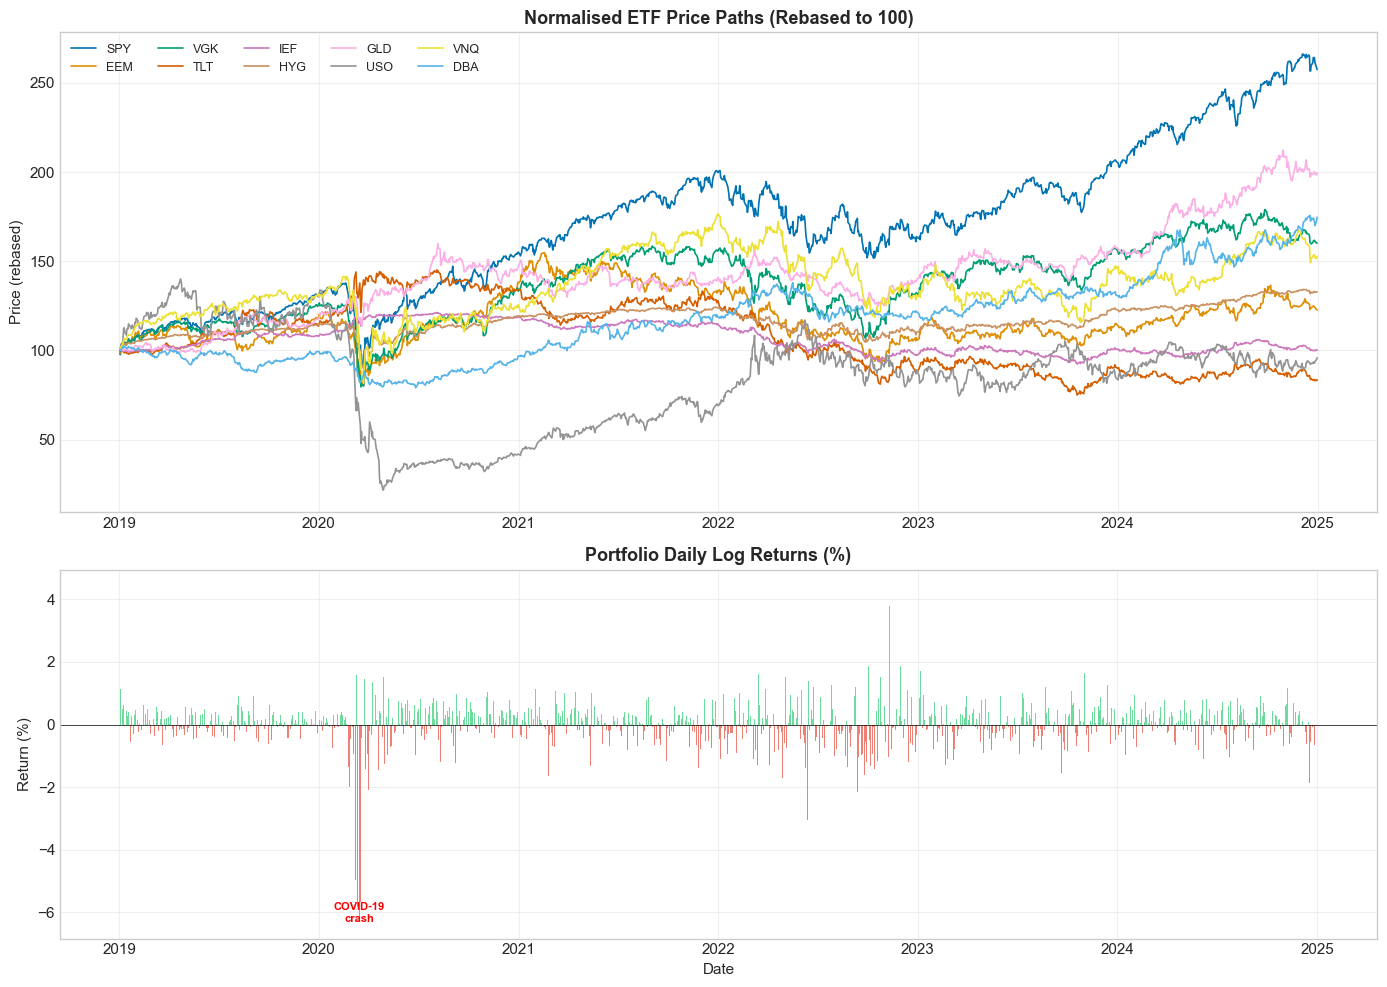

💾 Plot saved as '01_price_paths_and_returns.png'


In [7]:
# ============================================================
# 1.7 — VISUALISE CLEAN DATA
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1.3, 1]})

# ─────────────────────────────────────
# PLOT 1: Normalised price paths (rebased to 100)
# ─────────────────────────────────────
ax1 = axes[0]
normalised = (prices_clean / prices_clean.iloc[0]) * 100   # Rebase: first day = 100

for ticker in TICKERS:
    ax1.plot(normalised.index, normalised[ticker], label=ticker, linewidth=1.2)

ax1.set_title('Normalised ETF Price Paths (Rebased to 100)', fontweight='bold')
ax1.set_ylabel('Price (rebased)')
ax1.legend(loc='upper left', ncol=5, fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, alpha=0.3)

# ─────────────────────────────────────
# PLOT 2: Portfolio daily returns
# ─────────────────────────────────────
ax2 = axes[1]

# Bar-style plot of returns — colour by sign (green = positive, red = negative)
colours = ['#2ecc71' if r >= 0 else '#e74c3c' for r in portfolio_returns]
ax2.bar(portfolio_returns.index, portfolio_returns * 100, color=colours, width=1.0, alpha=0.7)

ax2.set_title('Portfolio Daily Log Returns (%)', fontweight='bold')
ax2.set_ylabel('Return (%)')
ax2.set_xlabel('Date')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.grid(True, alpha=0.3)

# --- Annotate key events ---
ax2.annotate('COVID-19\ncrash',
             xy=(pd.Timestamp('2020-03-16'), portfolio_returns.loc['2020-03-16'] * 100)
             if '2020-03-16' in portfolio_returns.index.strftime('%Y-%m-%d').tolist()
             else (pd.Timestamp('2020-03-16'), -5),
             fontsize=8, color='red', fontweight='bold',
             ha='center')

plt.tight_layout()
plt.savefig('01_price_paths_and_returns.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Plot saved as '01_price_paths_and_returns.png'")


## 1.8 — Save Clean Data for Subsequent Sections

We save the cleaned prices, individual returns, and portfolio returns for use in later sections.
This avoids re-downloading data when re-running individual sections.


In [8]:
# ============================================================
# 1.8 — SAVE CLEAN DATA
# ============================================================
# Save to CSV so later sections can load without re-downloading.
# Parquet would be faster for large datasets, but CSV is more portable.

prices_clean.to_csv('data_prices_clean.csv')
returns.to_csv('data_returns.csv')
portfolio_returns.to_frame('Portfolio').to_csv('data_portfolio_returns.csv')

print("💾 Data saved to disk:")
print(f"   data_prices_clean.csv      ({prices_clean.shape[0]} × {prices_clean.shape[1]})")
print(f"   data_returns.csv           ({returns.shape[0]} × {returns.shape[1]})")
print(f"   data_portfolio_returns.csv ({portfolio_returns.shape[0]} × 1)")


💾 Data saved to disk:
   data_prices_clean.csv      (1510 × 10)
   data_returns.csv           (1509 × 10)
   data_portfolio_returns.csv (1509 × 1)


---

## ✅ Section 1 — Summary

| Deliverable | Status | Details |
|-------------|:------:|---------|
| Clean prices | ✅ | `prices_clean` — T × 10 DataFrame |
| Individual log returns | ✅ | `returns` — (T−1) × 10 DataFrame |
| Portfolio returns | ✅ | `portfolio_returns` — (T−1) × 1 Series |
| Data quality report | ✅ | Zero-return streaks, outliers, alignment checked |
| Saved to disk | ✅ | 3 CSV files for use in later sections |

**Key observations from the data:**
- The portfolio spans ~6 years of daily data including major market events (COVID-19 crash, 2022 rate hiking cycle)
- This diversity of regimes will be crucial for stress-testing our VaR models
- Volatility clustering is already visually apparent in the portfolio return chart

**Next → Section 2: Exploratory Analysis** — We will examine distributional properties (fat tails, skewness, kurtosis), 
test for volatility clustering (Ljung-Box on squared returns), and establish the stylised facts that motivate 
GARCH modelling and explain why Parametric VaR fails.
